In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import model_definition as m


In [2]:
h5_file = h5py.File('/new_emit_dataset_vol/just_hypercubes/20230403T111207/chip_0.h5', 'r')
h5_file


<HDF5 file "chip_0.h5" (mode r)>

In [3]:
h5_array = np.array(h5_file['hypercube'])
h5_array.shape


(128, 128, 285)

In [4]:
# CHW layout for plotting a single band as (H, W)
h5_chw = np.transpose(h5_array, (2, 1, 0))
h5_chw.shape


(285, 128, 128)

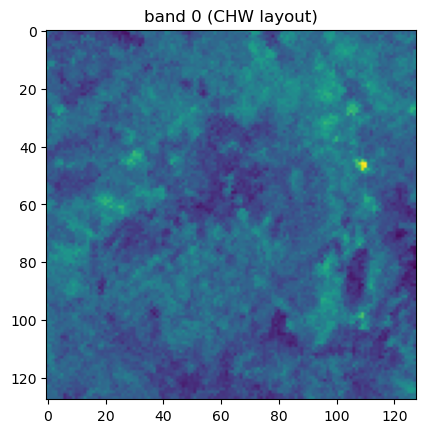

In [5]:
plt.imshow(h5_chw[0, :, :])
plt.title('band 0 (CHW layout)')
plt.show()


## Model setup + smoke test
Model input layout is `(B, H, W, C)` — use raw `hypercube` from h5, not the transposed CHW array.


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = m.SimpleHyperspectralMAEEncoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

x_smoke = torch.randn(2, 128, 128, 285, device=device)
loss_smoke = model(x_smoke)
loss_smoke.backward()
print('smoke test loss:', loss_smoke.item())


smoke test loss: 1.333497166633606


## Real chip: forward, overfit, visualize


In [7]:
chip_hwc = np.array(h5_file['hypercube'], dtype=np.float32)
print('chip shape (H, W, C):', chip_hwc.shape)

batch = torch.from_numpy(chip_hwc).unsqueeze(0).to(device)
print('batch shape:', batch.shape)


chip shape (H, W, C): (128, 128, 285)
batch shape: torch.Size([1, 128, 128, 285])


In [8]:
model.zero_grad(set_to_none=True)
loss = model(batch)
print('loss:', loss.item())
loss.backward()
optimizer.step()
print('backward OK')


loss: 18.1284236907959
backward OK


step    1  loss 17.620249
step   50  loss 9.390221
step  100  loss 6.494864
step  150  loss 5.668128
step  200  loss 5.237146
step  250  loss 4.932800
step  300  loss 4.773499
step  350  loss 4.936501
step  400  loss 4.802508
step  450  loss 4.737876
step  500  loss 4.774679
step  550  loss 4.710104
step  600  loss 4.584435
step  650  loss 4.597230
step  700  loss 4.693202
step  750  loss 4.447773
step  800  loss 4.765292
step  850  loss 4.423873
step  900  loss 4.568666
step  950  loss 4.500815
step 1000  loss 4.680090


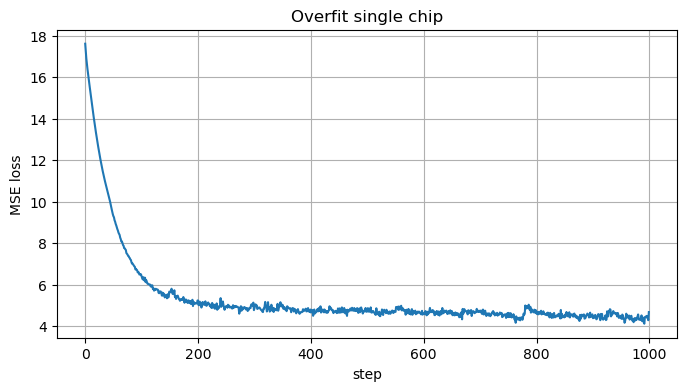

In [9]:
num_steps = 1000
log_every = 50
loss_history = []

model.train()
for step in range(1, num_steps + 1):
    model.zero_grad(set_to_none=True)
    loss = model(batch)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if step % log_every == 0 or step == 1:
        print(f'step {step:4d}  loss {loss.item():.6f}')

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('step')
plt.ylabel('MSE loss')
plt.title('Overfit single chip')
plt.grid(True)
plt.show()


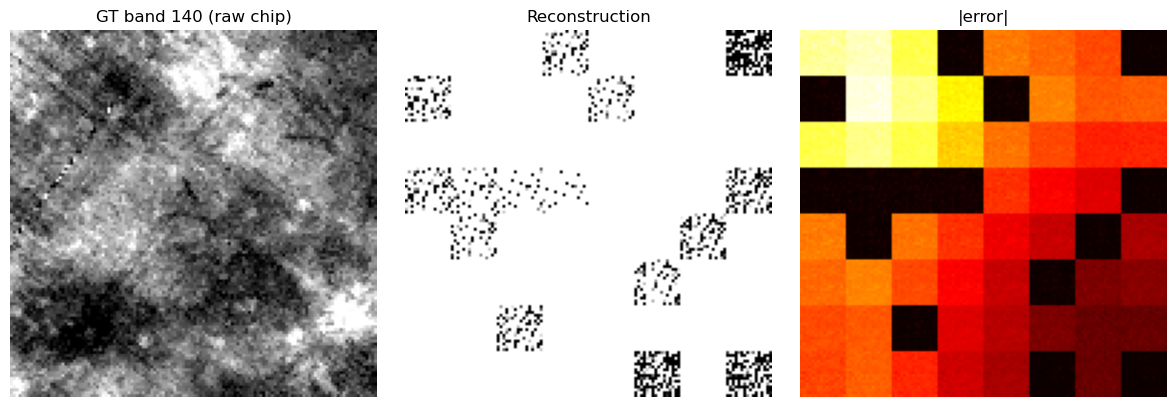

patchify roundtrip max |err|: 0.0
holistic MSE: 4.3500566


In [10]:
model.eval()
torch.manual_seed(0)
pred_hwc, _ = model.reconstruct(batch)
pred_np = pred_hwc[0].cpu().numpy()

band_idx = 140
vmin = np.percentile(chip_hwc[:, :, band_idx], 2)
vmax = np.percentile(chip_hwc[:, :, band_idx], 98)
err_np = np.abs(pred_np - chip_hwc)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(chip_hwc[:, :, band_idx], cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title(f'GT band {band_idx} (raw chip)')
axes[1].imshow(pred_np[:, :, band_idx], cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('Reconstruction')
axes[2].imshow(err_np[:, :, band_idx], cmap='hot')
axes[2].set_title('|error|')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

rt_err = (model.unpatchify(model.patchify(batch))[0].cpu().numpy() - chip_hwc).max()
print('patchify roundtrip max |err|:', rt_err)
print('holistic MSE:', np.mean((pred_np - chip_hwc) ** 2))
